In [1]:
import glob
import json
import gc
import os
import pandas as pd
import shutil
import numpy as np
from dotenv import load_dotenv
from huggingface_hub import login, snapshot_download, hf_hub_download, upload_file
from transformer_lens import HookedTransformer

from config import RunConfig
from utils import (
    build_classifiers,
    create_results_path,
    load_trained_clfs,
    save_clf_with_skops,
    save_dataset_locally,
    split_by_layer,
    upload_repo_to_hf,
    extract_model_activations,
safe_roc_auc, upload_repo_to_hf,
make_chat_settings
)
from sklearn.metrics import classification_report
from probes_dataset_creation_script import (
    create_canonical_dataset,
    distractor_word_data,
    neutral_filler_data,
    no_rule_keyword,
    opposite_statuses_rules,
    #canonical_test_heldout_split
)
from train_probes import training
from evaluate_probes import evaluate
from plot_probes import (
    accuracies_from_evaluation_results,
    plot_accuracy_per_layer,
    plot_auroc_curves,
)
from control_experiments import (
    distractor_control,
    double_rule_control,
    neutral_filler_control,
    no_keyword_control,
    p_value_control,
    train_on_shuffled_labels,
    weights_vs_diff_of_means,
)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.metrics import classification_report
import skops.io as sio
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from matplotlib import pyplot as plt

from scipy.spatial.distance import pdist, squareform
from skbio.stats.distance import DistanceMatrix, anosim, permanova
from sklearn.metrics.pairwise import cosine_distances

In [2]:
login()

## Cross-lingual consistency: 

# Does the same semantic rule occupy a similar direction/region across languages?

In [3]:
repo_ix = "veerlosar/prism-model-activations"
repo_type = "dataset"
selected_langs = ['en', 'de', 'it', 'yo', 'hi', 'ig', 'ru', 'ur']
n_layers = 32

In [4]:
df_path = hf_hub_download(repo_ix, "full_adherence_gpt_mini.parquet", repo_type="dataset")
fulldf = pd.read_parquet(df_path)

In [5]:
def unit(v):
    """L2-normalise; returns zeros unchanged rather than dividing by 0."""
    n = np.linalg.norm(v)
    return v if n == 0 else v / n

# DOMs are computed between obeyed and broken rules
def get_dom(X_layer, y):
    """Returns a UNIT vector."""
    return unit(X_layer[y == 1].mean(0) - X_layer[y == 0].mean(0))

In [14]:
%%time
# getting doms per language, loading a data vectors
doms_per_lang = {}
for lang in selected_langs:
    doms_per_lang[lang] = {}
    # loading X
    print(f'Loading results for {lang}...')
    x_path = hf_hub_download(
        repo_ix,
        f"meta-llama/Llama-3.1-8B-Instruct/adherence_gpt_mini_activations/X_adh_{lang}.npy",
        repo_type="dataset"
    )
    X = np.load(x_path)
    # loading y
    y_path = hf_hub_download(
        repo_ix,
        f"meta-llama/Llama-3.1-8B-Instruct/adherence_gpt_mini_activations/y_adh_{lang}.npy",
        repo_type="dataset"
    )
    y = np.load(y_path)
    X_dict = split_by_layer(X)
    del X
    gc.collect()
    print('Computing doms for', lang)
    for layer in range(n_layers):
        doms_per_lang[lang][layer] = get_dom(X_dict[layer], y)
    del y
    gc.collect()

Loading results for en...


meta-llama/Llama-3.1-8B-Instruct/adheren(…): reconstructing file:   0%|          |  0.00B / 7.36GB            

meta-llama/Llama-3.1-8B-Instruct/adheren(…): downloading bytes:           |  0.00B            

meta-llama/Llama-3.1-8B-Instruct/adheren(…): reconstructing file:   0%|          |  0.00B /  112kB            

meta-llama/Llama-3.1-8B-Instruct/adheren(…): downloading bytes:           |  0.00B            

Computing doms for en
Loading results for de...
Computing doms for de
Loading results for it...
Computing doms for it
Loading results for yo...
Computing doms for yo
Loading results for hi...
Computing doms for hi
Loading results for ig...
Computing doms for ig
Loading results for ru...
Computing doms for ru
Loading results for ur...
Computing doms for ur
CPU times: user 31.6 s, sys: 28.5 s, total: 1min
Wall time: 2min 43s


In [16]:
doms_per_lang.keys(), doms_per_lang['hi'].keys(), doms_per_lang['hi'][0]

(dict_keys(['en', 'de', 'it', 'yo', 'hi', 'ig', 'ru', 'ur']),
 dict_keys([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31]),
 array([-0.0103595 , -0.01864771, -0.00071739, ..., -0.00370176,
         0.00717157,  0.00065385], shape=(4096,), dtype=float32))

In [17]:
# creating sim matrix per layer
dom_matrices_per_layer = {}
for layer in range(n_layers):
    dom_matrices_per_layer[layer] = np.vstack([doms_per_lang[lang][layer] for lang in selected_langs])

In [18]:
cossim_per_layer = {
    layer: cosine_similarity(matrix) for layer, matrix in dom_matrices_per_layer.items()
}

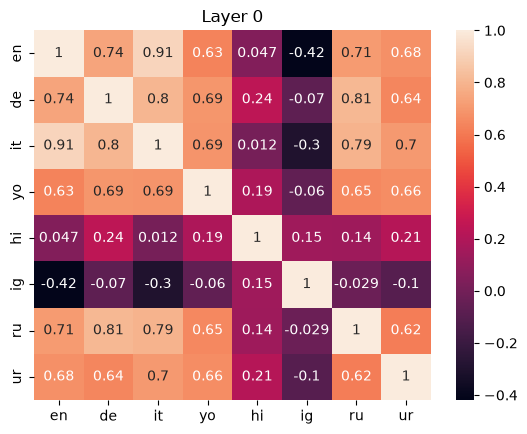

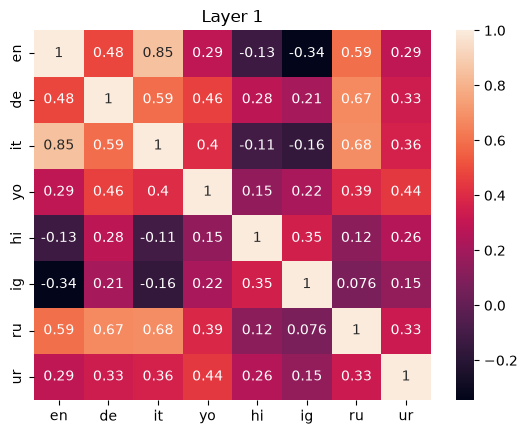

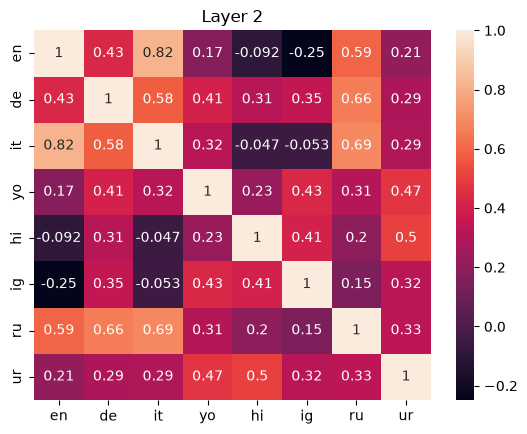

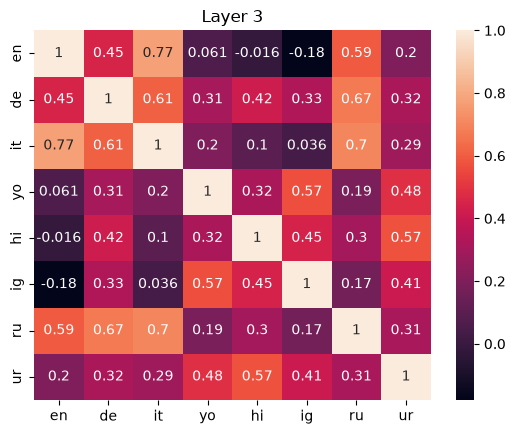

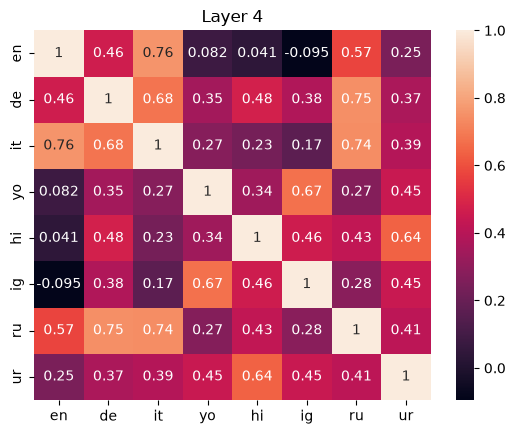

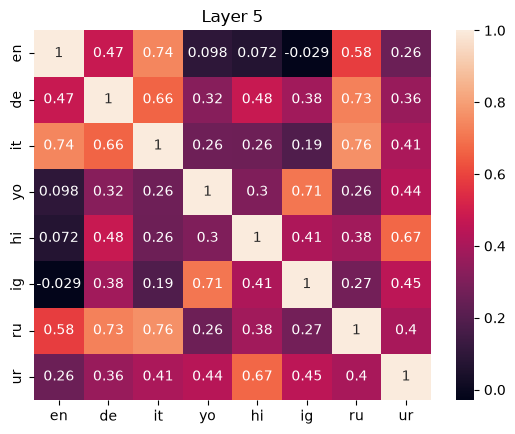

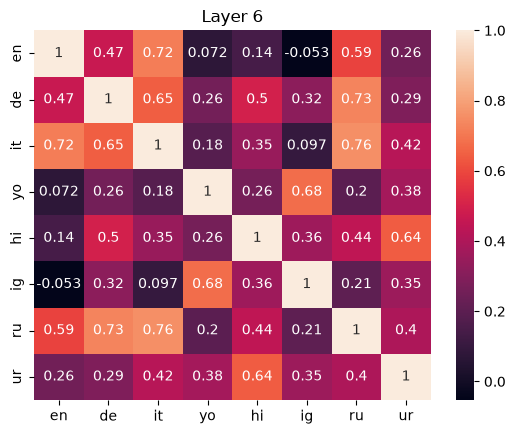

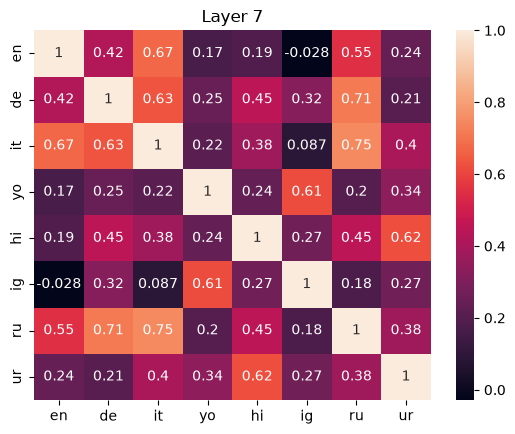

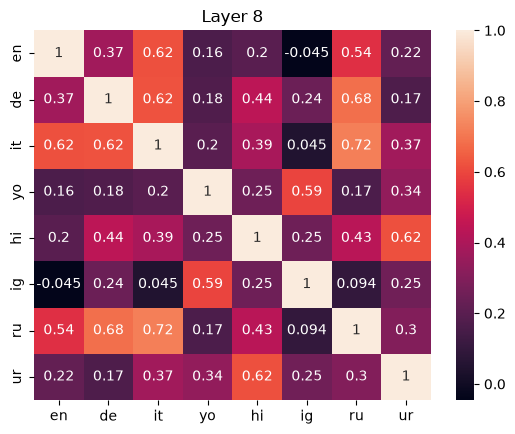

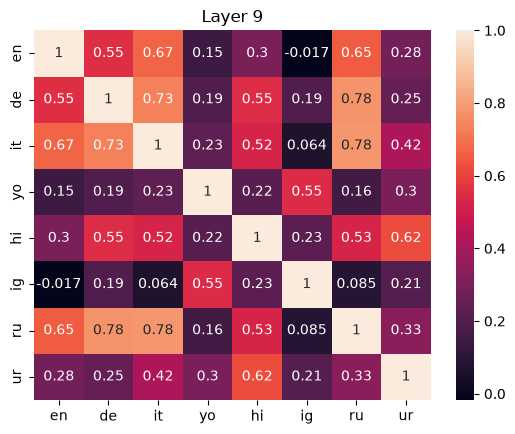

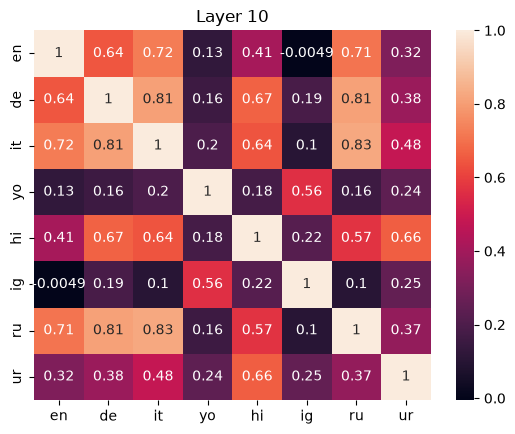

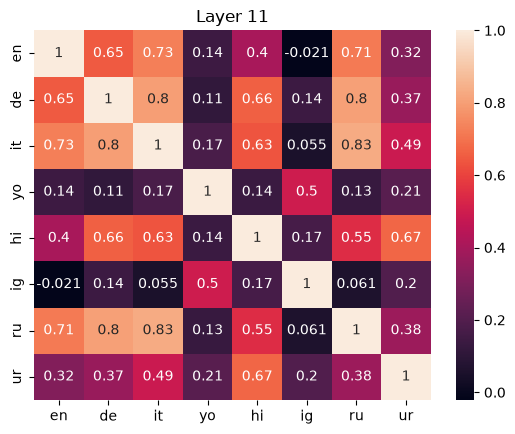

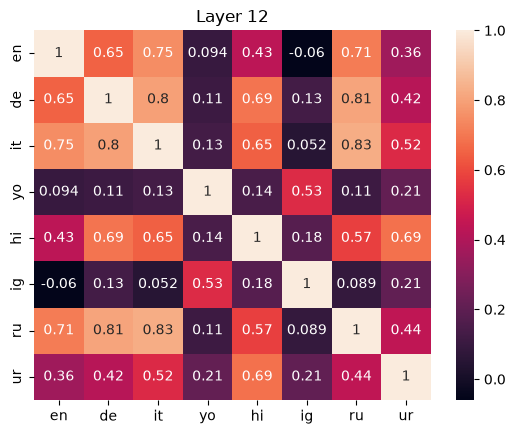

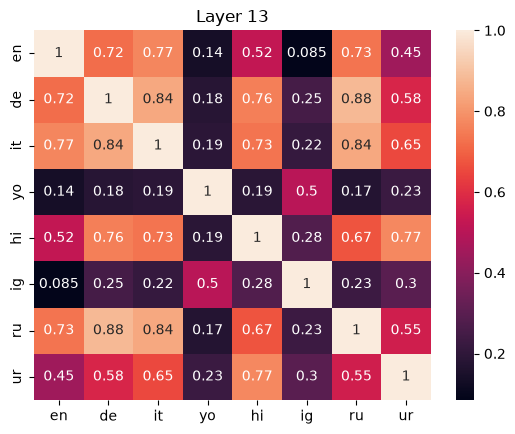

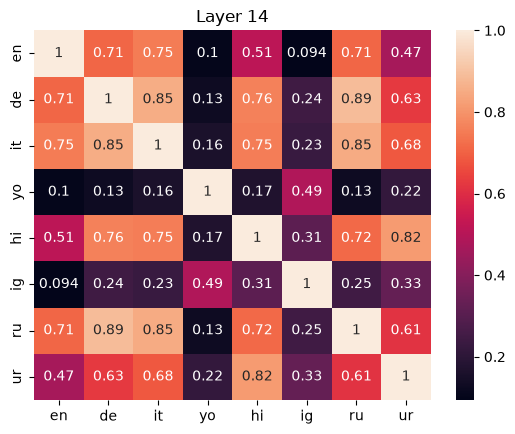

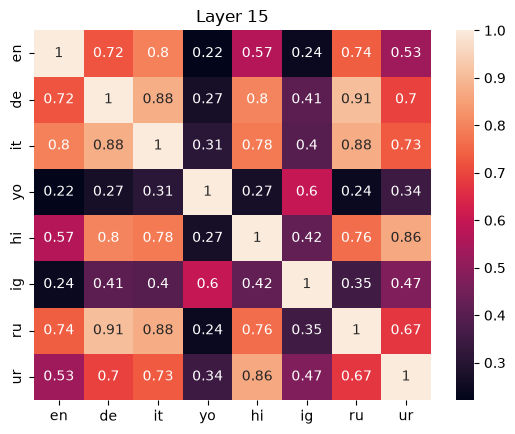

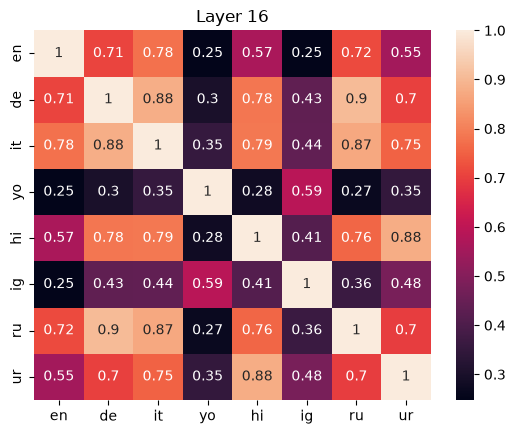

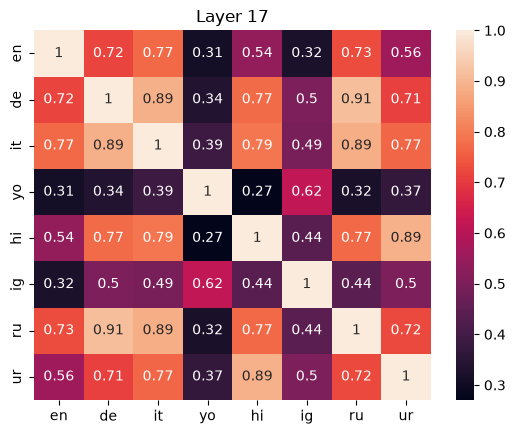

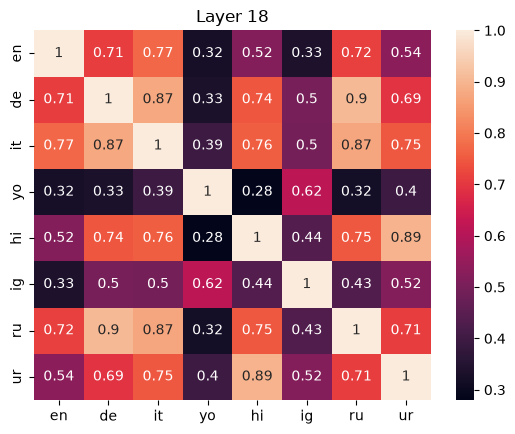

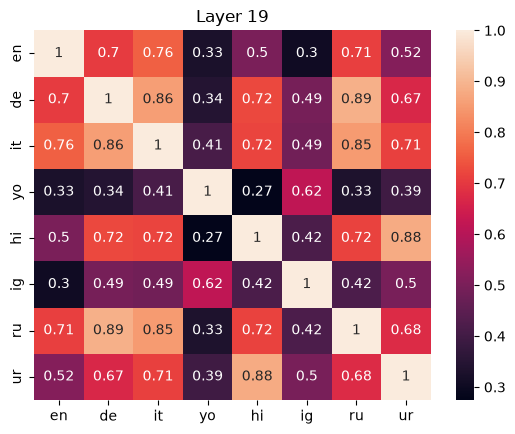

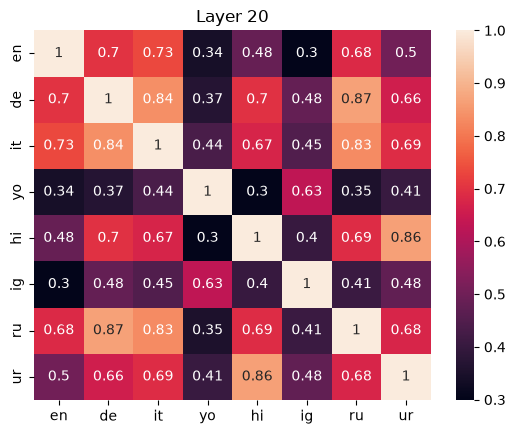

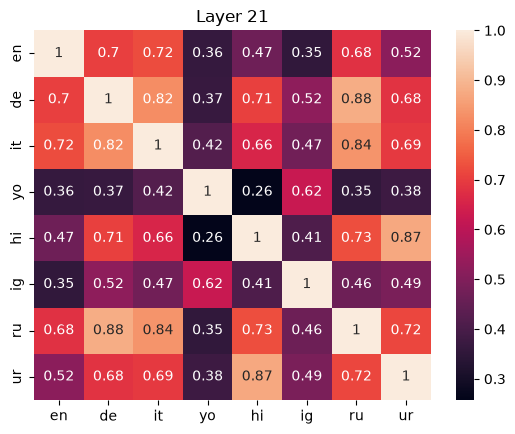

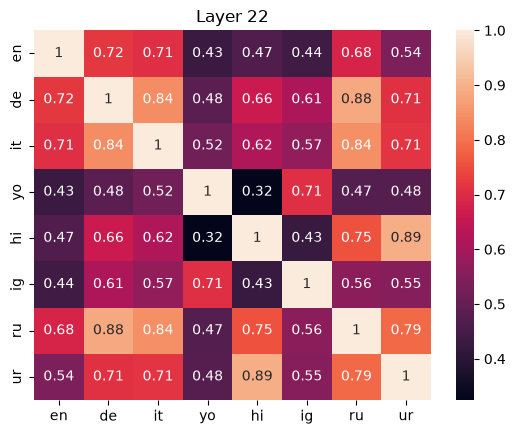

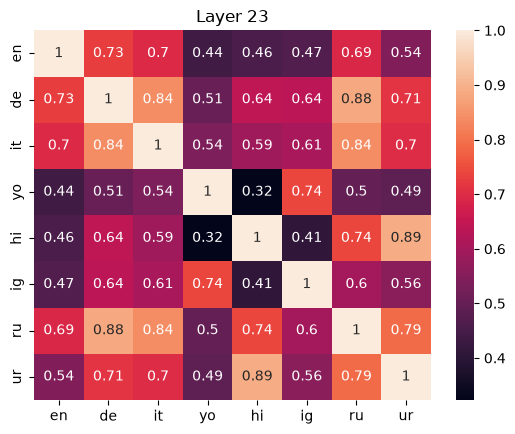

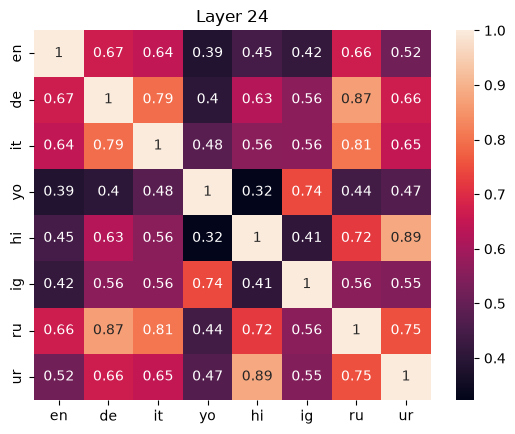

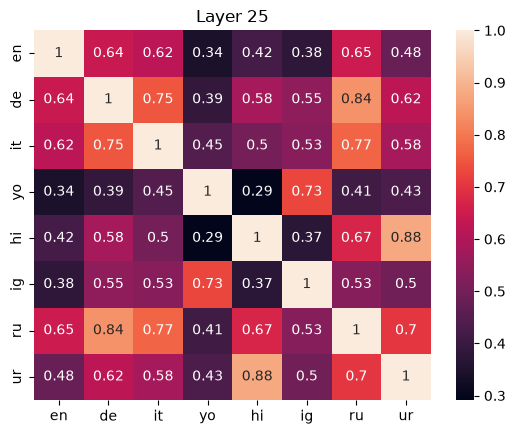

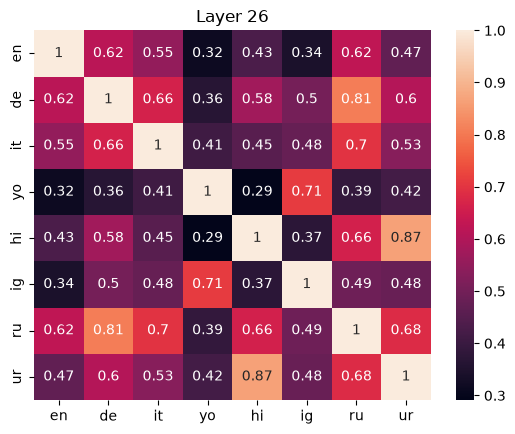

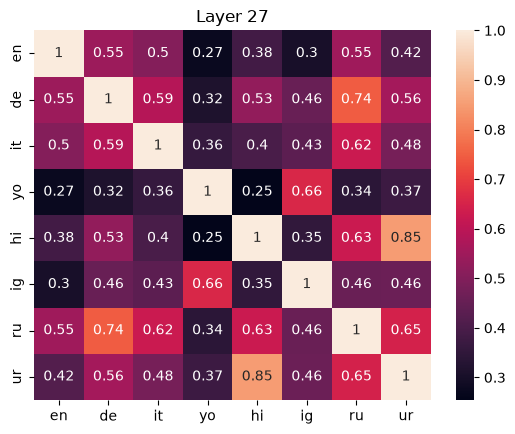

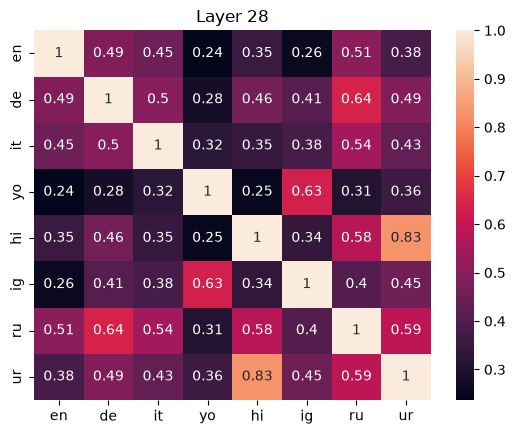

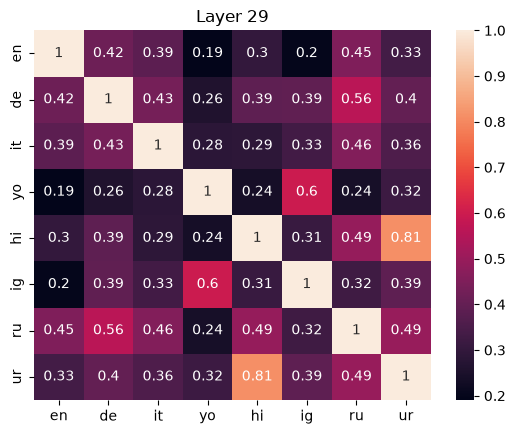

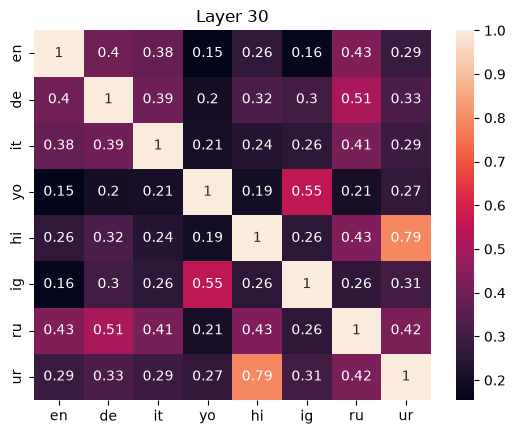

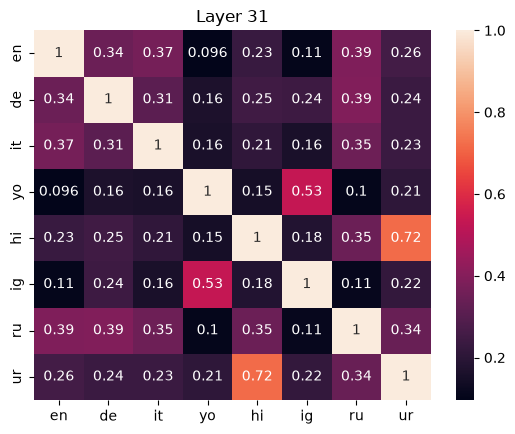

In [24]:
for layer, matrix in cossim_per_layer.items():
    plt.figure()
    sns.heatmap(matrix, xticklabels=selected_langs, yticklabels=selected_langs, annot=True)
    plt.title(f"Layer {layer}")
    plt.show()

In [36]:
'''Plotting mean per layer'''

'Plotting mean per layer'

In [38]:
mean_per_layer = []
for layer, mat in cossim_per_layer.items():
    upper_tri_indices = np.triu_indices_from(mat, k=1)
    mean_similarity = np.mean(mat[upper_tri_indices])
    mean_per_layer.append(mean_similarity)

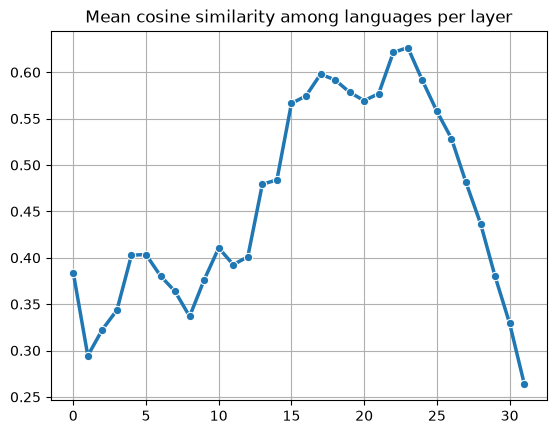

In [44]:
plt.figure()
sns.lineplot(x=range(n_layers), y=mean_per_layer, marker="o", linewidth=2.5)
plt.title("Mean cosine similarity among languages per layer")
plt.grid()
plt.show()

## Projecting vectors on dom

In [47]:
%%time
# saving vector projections
for lang in selected_langs:
    pass
    # loading X
    #print(f'Loading results for {lang}...')
    #x_path = hf_hub_download(
    #    repo_ix,
    #    f"meta-llama/Llama-3.1-8B-Instruct/adherence_gpt_mini_activations/X_adh_{lang}.npy",
    #    repo_type="dataset"
    #)
    #X = np.load(x_path)
    # loading y
    #y_path = hf_hub_download(
    #    repo_ix,
    #    f"meta-llama/Llama-3.1-8B-Instruct/adherence_gpt_mini_activations/y_adh_{lang}.npy",
    #    repo_type="dataset"
    #)
    #y = np.load(y_path)
    #X_dict = split_by_layer(X)
    #del X
    #gc.collect()

CPU times: user 8 μs, sys: 0 ns, total: 8 μs
Wall time: 12.9 μs


# Structure within and across rule categories

In [6]:
fulldf.columns, fulldf['category'].unique().shape

(Index(['id', 'model_id', 'language', 'category', 'topic', 'grammar_type',
        'pressure_level', 'pressure_name', 'pair_type', 'sample_idx',
        'violation_event', 'rule_status', 'checker_type', 'rubric_source',
        'rule_clause', 'user_query', 'response', 'judge_model', 'verdict',
        'reasoning', 'error', 'regex_applicable', 'regex_signal',
        'regex_agrees', 'category_check_applicable', 'category_check_result',
        'category_check_agrees', 'label', 'system_rule'],
       dtype='str'),
 (7,))

In [9]:
%%time
cats_per_lang = {}
for lang in selected_langs:
    cats_per_lang[lang] = {}
    cat_labels = fulldf.loc[fulldf['language'] == lang]['category'].tolist()
    # loading X
    print('Loading X from HF...', lang)
    x_path = hf_hub_download(
        repo_ix,
        f"meta-llama/Llama-3.1-8B-Instruct/adherence_gpt_mini_activations/X_adh_{lang}.npy",
        repo_type="dataset"
    )
    X = np.load(x_path)
    X_dict = split_by_layer(X)
    del X
    gc.collect()
    # preparing for permanova
    print(lang, 'Computing permanova per layer')
    for layer in range(n_layers):
        print(layer, end="\r")
        distance_array = cosine_distances(X_dict[layer])
        sample_ids = [f"{lang}_layer{layer}_sample{i}" for i in range(X_dict[layer].shape[0])]
        del X_dict[layer]
        gc.collect()
        dm = DistanceMatrix(distance_array, ids=sample_ids)
        del distance_array
        gc.collect()
        permanova_series = permanova(
            distance_matrix=dm,
            grouping=cat_labels,
            permutations=999,
        )
        cats_per_lang[lang][layer] = permanova_series.to_dict()
        del dm
        gc.collect()

Loading X from HF... en
en Computing permanova per layer
Loading X from HF... de
de Computing permanova per layer
Loading X from HF... it
it Computing permanova per layer
Loading X from HF... yo
yo Computing permanova per layer
Loading X from HF... hi
hi Computing permanova per layer
Loading X from HF... ig
ig Computing permanova per layer
Loading X from HF... ru
ru Computing permanova per layer
Loading X from HF... ur
ur Computing permanova per layer
CPU times: user 11h 21min 5s, sys: 9min 8s, total: 11h 30min 14s
Wall time: 1h 23min 17s


In [10]:
cats_per_lang['en'][0].keys()

dict_keys(['method name', 'test statistic name', 'sample size', 'number of groups', 'test statistic', 'p-value', 'number of permutations'])

In [14]:
lang_stats_per_layer = [
    [cats_per_lang[lang][l]['test statistic']
     for l in cats_per_lang[lang].keys()] for lang in cats_per_lang.keys()]

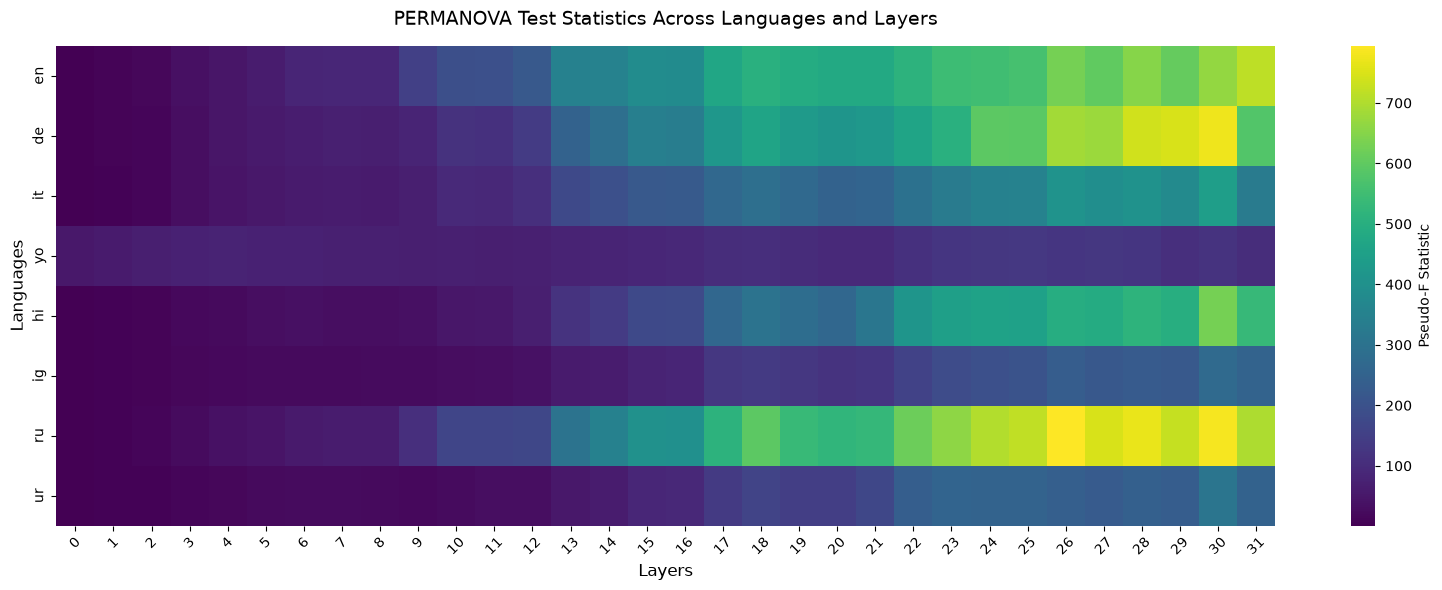

In [16]:
plt.figure(figsize=(16, 6))
sns.heatmap(
    lang_stats_per_layer, 
    xticklabels=range(n_layers), 
    yticklabels=cats_per_lang.keys(), 
    cmap="viridis",
    cbar_kws={'label': 'Pseudo-F Statistic'},
    #annot=True
)

plt.title("PERMANOVA Test Statistics Across Languages and Layers", fontsize=14, pad=15)
plt.xlabel("Layers", fontsize=12)
plt.ylabel("Languages", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Pseudo-F=Variance BETWEEN Groups (Signal)/Variance WITHIN Groups

The larger the pseudo-f is, the more distinct the rule categories are. In high-resource languages the representations of rule categories becomes very clear with the later layers. So rule categories definitely have their own recognised structure, especially in the later layers. However, low-resource languages fail to recognise it.

# Rules: similar within their language or across languages?

In [17]:
from itertools import combinations

In [18]:
# loading the activations
activations = {}

for lang in selected_langs:
    path = hf_hub_download(
        repo_id=repo_ix,
        filename=f"meta-llama/Llama-3.1-8B-Instruct/adherence_gpt_mini_activations/X_adh_{lang}.npy",
        repo_type=repo_type
    )
    activations[lang] = np.load(path, mmap_mode="r")

n_examples, n_layers, d_model = activations[selected_langs[0]].shape

In [28]:
import random

In [34]:
choice_activations = {}
for lang in activations.keys():
    choice_activations[lang] = {}
    choice_activations[lang] = split_by_layer(activations[lang][range(20), :, :])

In [35]:
choice_activations['en'][0].shape

(20, 4096)

## How are the rules similar to each other within a language

In [ ]:
target_layers = [10, 24]

In [36]:
target_langs = ['en', 'ru', 'yo', 'ig']

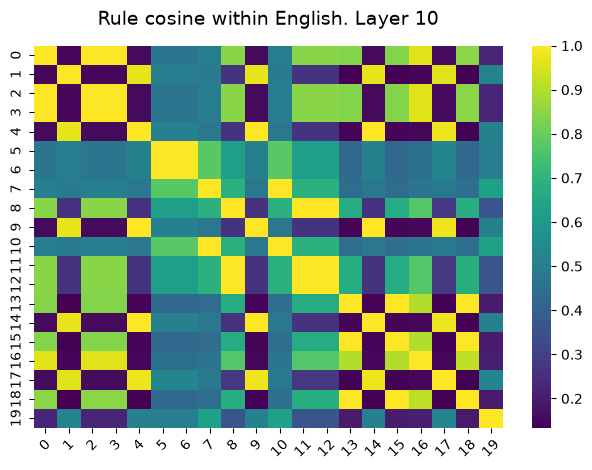

In [38]:
plt.figure()
sns.heatmap(
    cosine_similarity(choice_activations['en'][10]), 
    xticklabels=range(20), 
    yticklabels=range(20), 
    cmap="viridis",
    #cbar_kws={'label': },
    #annot=True
)

plt.title('Rule cosine within English. Layer 10', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

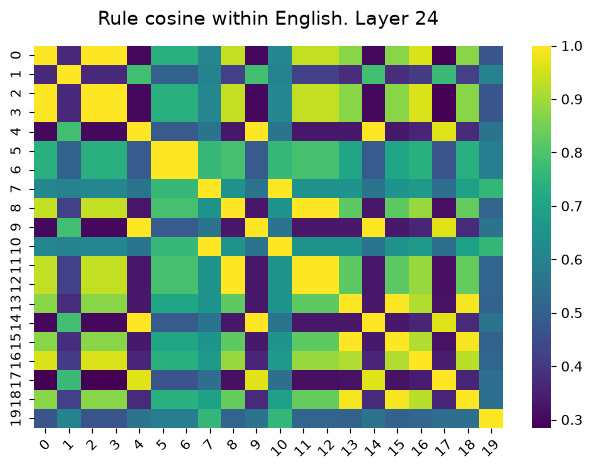

In [39]:
plt.figure()
sns.heatmap(
    cosine_similarity(choice_activations['en'][24]), 
    xticklabels=range(20), 
    yticklabels=range(20), 
    cmap="viridis",
    #cbar_kws={'label': },
    #annot=True
)

plt.title('Rule cosine within English. Layer 24', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

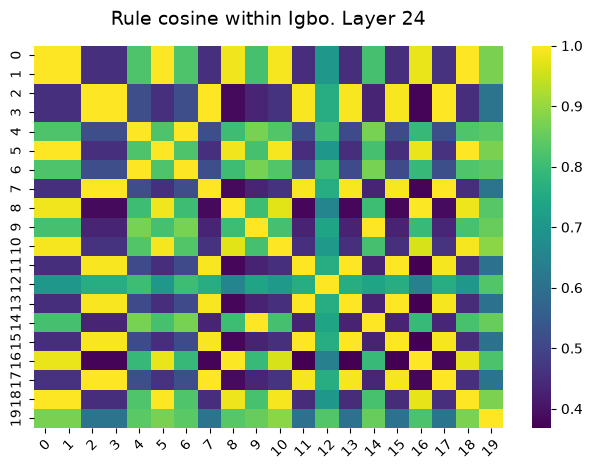

In [45]:
plt.figure()
sns.heatmap(
    cosine_similarity(choice_activations['ig'][24]), 
    xticklabels=range(20), 
    yticklabels=range(20), 
    cmap="viridis",
    #cbar_kws={'label': },
    #annot=True
)

plt.title('Rule cosine within Igbo. Layer 24', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

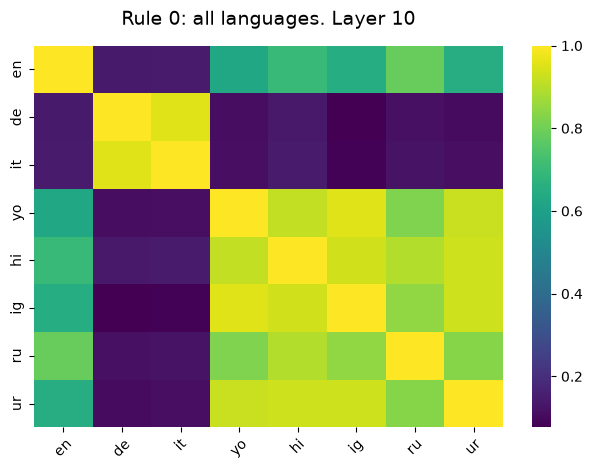

In [42]:
# layer 10, rule 0
across_mat = np.vstack(
    [choice_activations[lang][10][0] for lang in selected_langs]
)
plt.figure()
sns.heatmap(
    cosine_similarity(across_mat), 
    xticklabels=selected_langs, 
    yticklabels=selected_langs, 
    cmap="viridis",
    #cbar_kws={'label': },
    #annot=True
)

plt.title('Rule 0: all languages. Layer 10', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

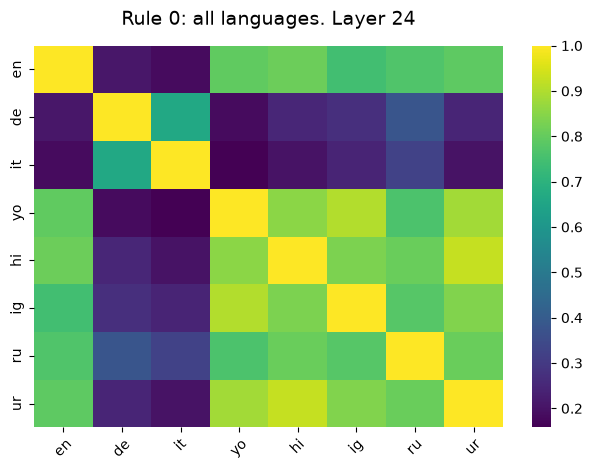

In [43]:
# layer 24, rule 0
across_mat = np.vstack(
    [choice_activations[lang][24][0] for lang in selected_langs]
)
plt.figure()
sns.heatmap(
    cosine_similarity(across_mat), 
    xticklabels=selected_langs, 
    yticklabels=selected_langs, 
    cmap="viridis",
    #cbar_kws={'label': },
    #annot=True
)

plt.title('Rule 0: all languages. Layer 24', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

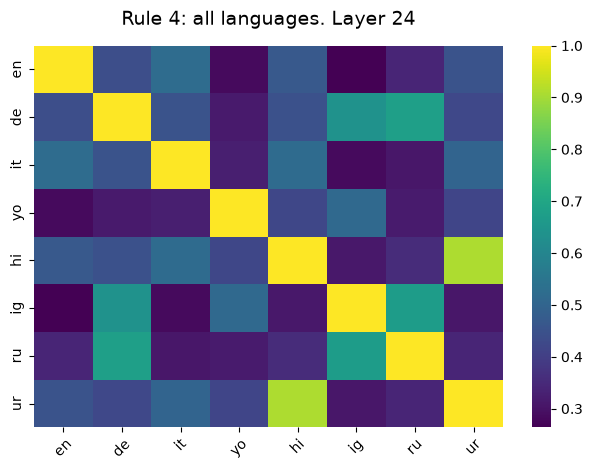

In [44]:
# layer 24, rule 4
across_mat = np.vstack(
    [choice_activations[lang][24][4] for lang in selected_langs]
)
plt.figure()
sns.heatmap(
    cosine_similarity(across_mat), 
    xticklabels=selected_langs, 
    yticklabels=selected_langs, 
    cmap="viridis",
    #cbar_kws={'label': },
    #annot=True
)

plt.title('Rule 4: all languages. Layer 24', fontsize=14, pad=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

It seems like rule similarity within or across languages is quite rule-dependent